# API Getting Started Guide

Make a HTTP GET request to a specified URL ("endpoint"), and verify that the response is successful. If the response type is JSON, then automatically decode it into a dict-like object.

In [1]:
import requests

baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"e7205be31fb9f9b069960f52cf1481c1"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)
    # the number we get at the response is the HTTP status code i.e. 404(not found), 200(OK), 500(internal server error)

    
    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status() #From the documentation,  it will tell the meaning of  every status code that is not successful

    #Every time a server sends a response, it includes a header—think of this like a shipping label on the outside of a box.
    #The content-type tells your code what is inside the box before you try to open it. 
    #If it says application/json: The server is sending a structured text file (like a list of galaxy coordinates).

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
        #json files are nothing more that dictionaries
    return r

Issue a request to the API root

In [2]:
r = get(baseUrl)

The response is a dictionary object with one key, "simulations", which is a list of N (currently 18 in this example) available runs:

In [3]:
r.keys() #keys of the json dictionary we recuested

dict_keys(['simulations'])

In [4]:
len(r["simulations"])

66

In [5]:
r["simulations"][65]

{'name': 'TNG50-4-Subbox1',
 'num_snapshots': 2333,
 'url': 'http://www.tng-project.org/api/TNG50-4-Subbox1/'}

Print out all fields of the first, as well as the names of all eighteen.

In [6]:
names = [sim['name'] for sim in r['simulations']]
names

['Illustris-1',
 'Illustris-1-Dark',
 'Illustris-2',
 'Illustris-2-Dark',
 'Illustris-3',
 'Illustris-3-Dark',
 'TNG100-1',
 'TNG100-1-Dark',
 'TNG100-2',
 'TNG100-2-Dark',
 'TNG100-3',
 'TNG100-3-Dark',
 'TNG300-3',
 'TNG300-2-Dark',
 'TNG300-2',
 'TNG300-1-Dark',
 'TNG300-1',
 'TNG300-3-Dark',
 'TNG50-1',
 'TNG50-1-Dark',
 'TNG50-2',
 'TNG50-2-Dark',
 'TNG50-3',
 'TNG50-3-Dark',
 'TNG50-4',
 'TNG50-4-Dark',
 'TNG-Cluster',
 'Illustris-1-Subbox0',
 'Illustris-1-Subbox1',
 'Illustris-1-Subbox2',
 'Illustris-1-Subbox3',
 'Illustris-2-Subbox0',
 'Illustris-2-Subbox1',
 'Illustris-2-Subbox2',
 'Illustris-2-Subbox3',
 'Illustris-3-Subbox0',
 'Illustris-3-Subbox1',
 'Illustris-3-Subbox2',
 'Illustris-3-Subbox3',
 'TNG100-1-Subbox0',
 'TNG100-1-Subbox1',
 'TNG100-2-Subbox0',
 'TNG100-2-Subbox1',
 'TNG100-3-Subbox0',
 'TNG100-3-Subbox1',
 'TNG300-3-Subbox1',
 'TNG300-3-Subbox2',
 'TNG300-3-Subbox0',
 'TNG300-2-Subbox1',
 'TNG300-2-Subbox2',
 'TNG300-2-Subbox0',
 'TNG300-1-Subbox1',
 'TNG300-1

We see the three resolution levels of Illustris, the three dark matter only runs, and the four subboxes per "full physics" run, as expected. Each entry has only three fields: name, num_snapshots, and url. We can retrieve the full metadata for a particular simulation by submitting a request to the specified url.

Let's look at TNG50-1 by determining which entry in r it is, then requesting the url field of that entry

In [7]:
i = names.index('TNG50-1')
i

18

In [8]:
sim=get(r["simulations"][i]["url"])

In [9]:
sim.keys()

dict_keys(['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', 'parent_simulation', 'child_s

In [10]:
sim["num_dm"]

10077696000

Next, get the snapshot listing for this simulation.

In [11]:
snaps=get(sim["snapshots"])
len(snaps)

100

There are 100 total snapshots, inspect the last one, which corresponds to z=0.

In [12]:
snaps[-1]

{'number': 99,
 'redshift': 2.22044604925031e-16,
 'num_groups_subfind': 5688113,
 'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/'}

Retrieve the full meta-data for this snapshot

In [13]:
snap=get(snaps[-1]["url"])
snap

{'simulation': 'http://www.tng-project.org/api/TNG50-1/',
 'number': 99,
 'redshift': 2.22044604925031e-16,
 'num_gas': 8737803526,
 'num_dm': 10077696000,
 'num_trmc': 10077696000,
 'num_stars': 1289575331,
 'num_bhs': 4055,
 'num_groups_fof': 10247012,
 'num_groups_subfind': 5688113,
 'num_groups_rockstar': 0,
 'filesize_snapshot': 2921762412696.0,
 'filesize_groupcat': 6321263889.0,
 'filesize_rockstar': 0.0,
 'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/',
 'subhalos': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/',
 'vis': {'groupcat_sfms': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=ssfr&xlim=9.0%2C11.0',
  'groupcat_sizemass': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=size_stars',
  'groupcat_mz_gas': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=Z_gas',
  'groupcat_mz_stars': 'http://www.tng-p

In addition to numeric meta-data fields such as num_gas at this snapshot, we have the url field, describing the location of this particular snapshot, which is exactly the URL which we just requested. The simulation links back to the parent simulation which owns this snapshot, while subhalos links deeper, to all the child subhalos which belong to this snapshot. Finally, the files dict contains entries for all "raw file" downloads available specifically for this snapshot. These are the same links you will find embedded in the wget commands for snapshot 135 on the TNG50-1 Downloads page.

In [14]:
subs=get(snap["subhalos"])
subs.keys()

dict_keys(['count', 'next', 'previous', 'results'])

In [15]:
subs["count"]

5688113

In [16]:
subs["next"]

'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/?limit=100&offset=100'

In [17]:
len(subs['results'])

100

The response is a paginated list of all Subfind subhalos which exist at this snapshot. The default page size is 100 elements, this can be overridden by specifying a limit parameter.

In [18]:
subs = get( snap['subhalos'], {'limit':220} )
len(subs['results'])

220

In [19]:
subs['next']

'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/?limit=220&offset=220'

In [20]:
subs['results'][0]

{'id': 0,
 'sfr': 1.15783,
 'mass_log_msun': 14.292666717121172,
 'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/99/subhalos/0/'}

Each element of results contains minimal information: the subhalo id, its total mass (log solar units), and its unique URL. Note that, although this is the first result of the first page, the ID may not necessarily be zero!

Request the first twenty subhalos at this snapshot, sorted by descending stellar mass

In [21]:
subs = get( snap['subhalos'], {'limit':20, 'order_by':'-mass_stars'} )
len(subs['results'])

20

In [22]:
[ subs['results'][i]['id'] for i in range(20) ]

[0,
 96762,
 63864,
 198182,
 117250,
 229933,
 208811,
 220595,
 253861,
 184931,
 275545,
 289385,
 319730,
 300903,
 282779,
 294866,
 167392,
 242788,
 313692,
 329508]

As expected, because subhalos within each halo are ordered roughly in order of decreasing total mass, the most massive subhalo (with ID==0) also has the most stars. The next ID (96762) is likely a central subhalo of a subsequent FoF halo.

Let's check. First, get the full subhalo information for ID==96762.

In [23]:
sub = get( subs['results'][1]['url'] )
sub

{'snap': 99,
 'id': 96762,
 'bhmdot': 0.00131954,
 'cm_x': 27098.9,
 'cm_y': 7572.82,
 'cm_z': 4058.59,
 'gasmetallicity': 0.0254955,
 'gasmetallicityhalfrad': 0.0347981,
 'gasmetallicitymaxrad': 0.0416485,
 'gasmetallicitysfr': 0.0314728,
 'gasmetallicitysfrweighted': 0.0350838,
 'pos_x': 27095.8,
 'pos_y': 7552.95,
 'pos_z': 4049.47,
 'halfmassrad': 267.791,
 'halfmassrad_gas': 352.092,
 'halfmassrad_dm': 260.91,
 'halfmassrad_stars': 12.72,
 'halfmassrad_bhs': 0.0,
 'len': 241449425,
 'len_gas': 86790745,
 'len_dm': 125929744,
 'len_stars': 28728934,
 'len_bhs': 2,
 'mass': 4510.77,
 'mass_gas': 527.754,
 'mass_dm': 3870.67,
 'mass_stars': 112.089,
 'mass_bhs': 0.248693,
 'massinhalfrad': 95.4452,
 'massinhalfrad_gas': 0.713947,
 'massinhalfrad_dm': 38.4379,
 'massinhalfrad_stars': 56.0447,
 'massinhalfrad_bhs': 0.248613,
 'massinmaxrad': 17.5254,
 'massinmaxrad_gas': 0.000502,
 'massinmaxrad_dm': 2.23435,
 'massinmaxrad_stars': 15.0419,
 'massinmaxrad_bhs': 0.248613,
 'massinrad': 

The response is a combination of numeric fields and links to related objects, as well as additional data.

Let us directly request a group catalog field dump of the parent FoF halo.

In [24]:
url = sub['related']['parent_halo'] + "info.json"
url

'http://www.tng-project.org/api/TNG50-1/snapshots/99/halos/2/info.json'

In [25]:
parent_fof=get(url)
parent_fof.keys()

dict_keys(['SimulationName', 'SnapshotNumber', 'InfoType', 'InfoID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200'])

In this case, we see that subhalo 1030 is indeed the central for this FoF 2, which has 366 total subhalos.

Let us return to the subhalo itself, and make some requests which return HDF5 data. First, extend our helper function so that if it recieves a binary response, it saves it to a file with the appropriate name (in the current working directory, customize as needed).

In [26]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

Now, request the main progenitor branch from the SubLink merger trees of this subhalo.

In [27]:
import h5py
mpb1 = get( sub['trees']['sublink_mpb'] ) # file saved, mpb1 contains the filename

In [57]:
f=h5py.File(mpb1,"r")
print(f.keys())

<KeysViewHDF5 ['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'Subh

In [29]:
print(len(f["SnapNum"]))

99


In [30]:
print(f["SnapNum"][:])

[99 98 97 96 95 94 93 92 91 90 89 88 87 86 85 84 83 82 81 80 79 78 77 76
 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52
 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28
 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4
  3  2  1]


Let's plot the evolution the subhalo position, along each coordinate axis, back in time.

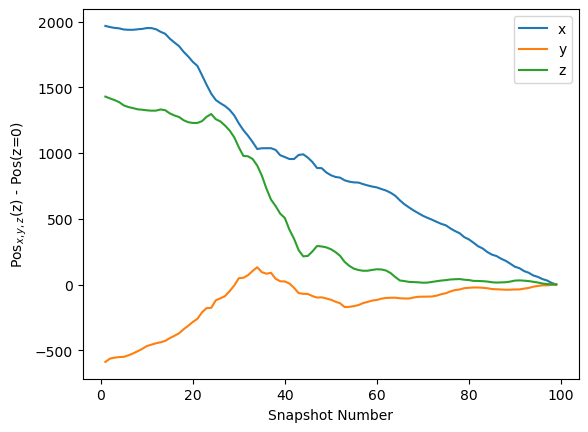

In [31]:
import matplotlib.pyplot as plt
with h5py.File(mpb1,'r') as f:
    pos = f['SubhaloPos'][:]
    snapnum = f['SnapNum'][:]

for i in range(3):
    plt.plot(snapnum,pos[:,i] - pos[0,i], label=['x','y','z'][i])
plt.legend()
plt.xlabel('Snapshot Number')
plt.ylabel('Pos$_{x,y,z}$(z) - Pos(z=0)');

Finally, let's get an actual cutout of snapshot data. Our goal: an image of the gas density around the z=1 progenitor of our subhalo.

First, what is the snapshot we are looking for?

In [32]:
url = sim['snapshots'] + "z=1/"
snap = get(url)
snap['number'], snap['redshift']

(50, 0.99729422578194)

Find the target Subfind ID at snapshot 50 using 
the Sublink tree.

In [56]:
import numpy as np
f=h5py.File(mpb1,"r")
i = np.where(f["SnapNum"][:] == 85)
f["SubfindID"][i][0]

np.int32(88199)

In [69]:
url ="http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/88199/"
sub=get(url)
sub

{'snap': 50,
 'id': 88199,
 'bhmdot': 0.0,
 'cm_x': 16002.8,
 'cm_y': 30030.2,
 'cm_z': 26110.7,
 'gasmetallicity': 0.0,
 'gasmetallicityhalfrad': 0.0,
 'gasmetallicitymaxrad': 0.0,
 'gasmetallicitysfr': 0.0,
 'gasmetallicitysfrweighted': 0.0,
 'pos_x': 16002.2,
 'pos_y': 30029.9,
 'pos_z': 26110.3,
 'halfmassrad': 3.0805,
 'halfmassrad_gas': 0.0,
 'halfmassrad_dm': 3.0805,
 'halfmassrad_stars': 0.0,
 'halfmassrad_bhs': 0.0,
 'len': 257,
 'len_gas': 0,
 'len_dm': 257,
 'len_stars': 0,
 'len_bhs': 0,
 'mass': 0.007899,
 'mass_gas': 0.0,
 'mass_dm': 0.007899,
 'mass_stars': 0.0,
 'mass_bhs': 0.0,
 'massinhalfrad': 0.0,
 'massinhalfrad_gas': 0.0,
 'massinhalfrad_dm': 0.0,
 'massinhalfrad_stars': 0.0,
 'massinhalfrad_bhs': 0.0,
 'massinmaxrad': 0.004119,
 'massinmaxrad_gas': 0.0,
 'massinmaxrad_dm': 0.004119,
 'massinmaxrad_stars': 0.0,
 'massinmaxrad_bhs': 0.0,
 'massinrad': 0.0,
 'massinrad_gas': 0.0,
 'massinrad_dm': 0.0,
 'massinrad_stars': 0.0,
 'massinrad_bhs': 0.0,
 'sfr': 0.0,
 'sf

Request the subhalo details, and a snapshot cutout consisting only of Gas fields Coordinates,Masses.

In [71]:
cutout_request = {'dm':'Coordinates'}
cutout = get(url+"/cutout.hdf5", cutout_request) #file saved
print(url+"cutout.hdf5")

http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/88199/cutout.hdf5


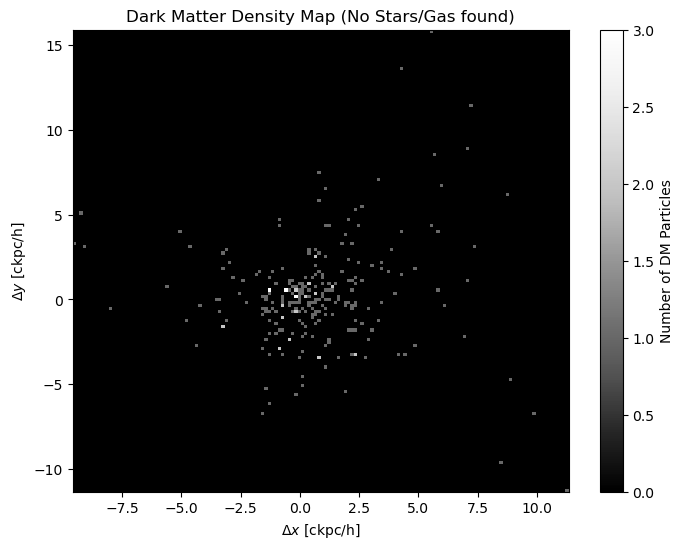

In [76]:
with h5py.File(cutout, 'r') as f:
    # Use PartType1 for Dark Matter
    # Use sub['pos'] instead of pos_x/pos_y to avoid KeyError
    x = f['PartType1']['Coordinates'][:,0] - sub['pos_x']
    y = f['PartType1']['Coordinates'][:,1] - sub['pos_y']

# Plot the Dark Matter distribution
plt.figure(figsize=(8,6))
# We don't use 'weights' here, just count the number of DM particles in each bin
plt.hist2d(x, y, bins=[150, 150], cmap='Greys_r') 

plt.xlabel('$\Delta x$ [ckpc/h]')
plt.ylabel('$\Delta y$ [ckpc/h]')
plt.title('Dark Matter Density Map (No Stars/Gas found)')
plt.colorbar(label='Number of DM Particles')
plt.show()